In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("datafile (1).csv")

In [5]:
df.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72


In [6]:
df.shape

(49, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Crop                                   49 non-null     object 
 1   State                                  49 non-null     object 
 2   Cost of Cultivation (`/Hectare) A2+FL  49 non-null     float64
 3   Cost of Cultivation (`/Hectare) C2     49 non-null     float64
 4   Cost of Production (`/Quintal) C2      49 non-null     float64
 5   Yield (Quintal/ Hectare)               49 non-null     float64
dtypes: float64(4), object(2)
memory usage: 2.4+ KB


In [8]:
df.columns

Index(['Crop', 'State', 'Cost of Cultivation (`/Hectare) A2+FL',
       'Cost of Cultivation (`/Hectare) C2',
       'Cost of Production (`/Quintal) C2', 'Yield (Quintal/ Hectare) '],
      dtype='object')

In [9]:
df.isnull().sum()

Crop                                     0
State                                    0
Cost of Cultivation (`/Hectare) A2+FL    0
Cost of Cultivation (`/Hectare) C2       0
Cost of Production (`/Quintal) C2        0
Yield (Quintal/ Hectare)                 0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
count,49.000000,49.000000,49.000000,49.000000
mean,20363.537347,31364.666735,1620.537755,98.086735
std,13561.435306,20095.783569,1104.990472,245.293123
min,5483.540000,7868.640000,85.790000,1.320000
25%,12774.410000,19259.840000,732.620000,9.590000
50%,17022.000000,25909.050000,1595.560000,13.700000
75%,24731.060000,35423.480000,2228.970000,36.610000
max,66335.060000,91442.630000,5777.480000,1015.450000


In [12]:
df["Crop"].unique()

array(['ARHAR', 'COTTON', 'GRAM', 'GROUNDNUT', 'MAIZE', 'MOONG', 'PADDY',
       'RAPESEED AND MUSTARD', 'SUGARCANE', 'WHEAT'], dtype=object)

In [13]:
df["Crop"].value_counts()

Crop
ARHAR                   5
COTTON                  5
GRAM                    5
GROUNDNUT               5
MAIZE                   5
MOONG                   5
PADDY                   5
RAPESEED AND MUSTARD    5
SUGARCANE               5
WHEAT                   4
Name: count, dtype: int64

In [14]:
df["State"].unique()

array(['Uttar Pradesh', 'Karnataka', 'Gujarat', 'Andhra Pradesh',
       'Maharashtra', 'Punjab', 'Haryana', 'Rajasthan', 'Madhya Pradesh',
       'Tamil Nadu', 'Bihar', 'Orissa', 'West Bengal'], dtype=object)

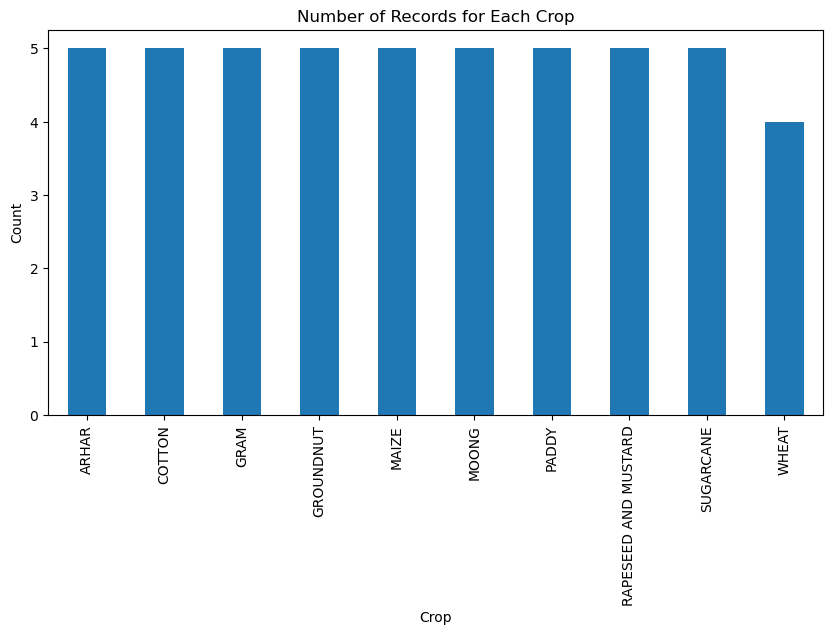

In [15]:
plt.figure(figsize=(10,5))

df["Crop"].value_counts().plot(kind="bar")

plt.title("Number of Records for Each Crop")
plt.xlabel("Crop")
plt.ylabel("Count")

plt.show()

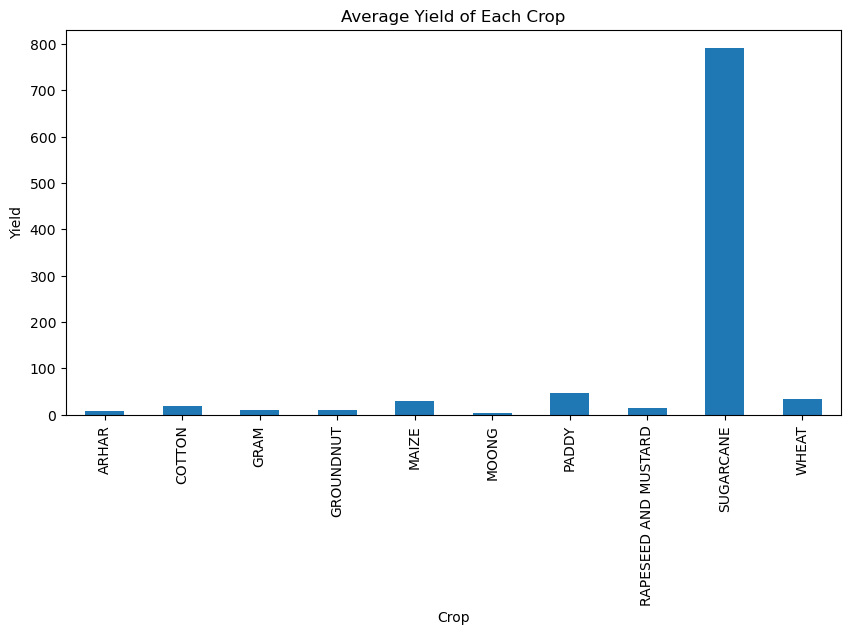

In [16]:
plt.figure(figsize=(10,5))

df.groupby("Crop")["Yield (Quintal/ Hectare) "].mean().plot(kind="bar")

plt.title("Average Yield of Each Crop")
plt.xlabel("Crop")
plt.ylabel("Yield")

plt.show()

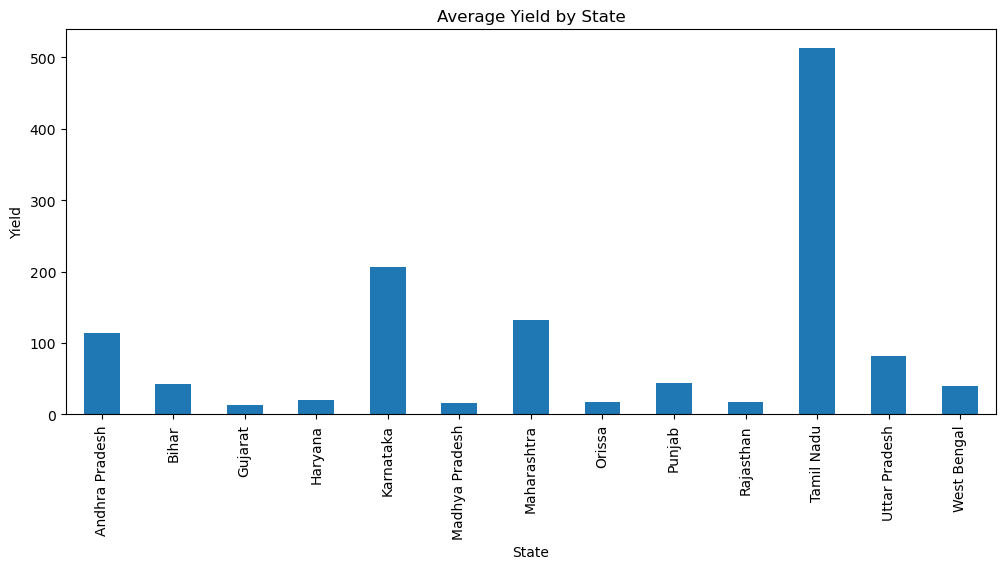

In [17]:
plt.figure(figsize=(12,5))

df.groupby("State")["Yield (Quintal/ Hectare) "].mean().plot(kind="bar")

plt.title("Average Yield by State")
plt.xlabel("State")
plt.ylabel("Yield")

plt.show()

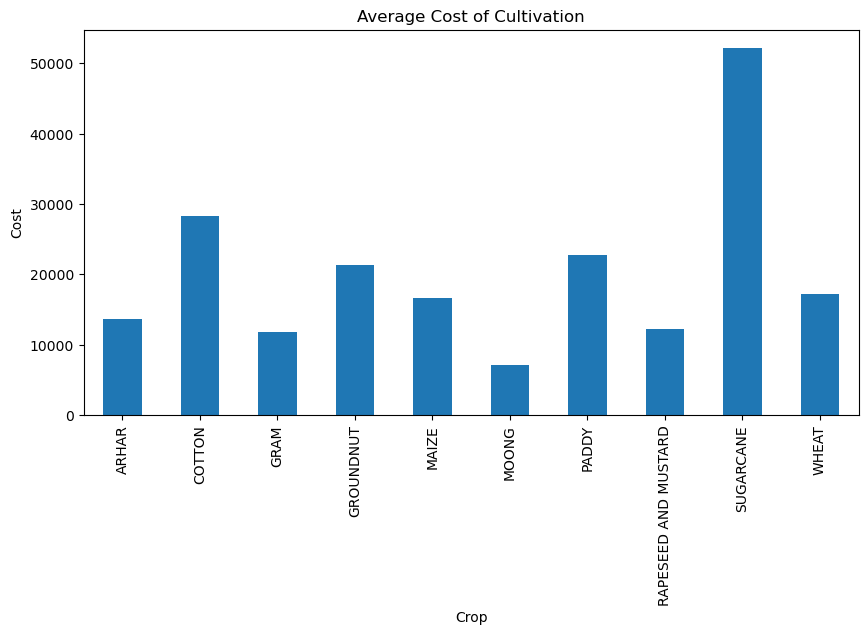

In [18]:
plt.figure(figsize=(10,5))

df.groupby("Crop")["Cost of Cultivation (`/Hectare) A2+FL"].mean().plot(kind="bar")

plt.title("Average Cost of Cultivation")
plt.xlabel("Crop")
plt.ylabel("Cost")

plt.show()

In [19]:
X = df.drop("Yield (Quintal/ Hectare) ", axis=1)

y = df["Yield (Quintal/ Hectare) "]

In [20]:
X.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55
1,ARHAR,Karnataka,10593.15,16528.68,2172.46
2,ARHAR,Gujarat,13468.82,19551.90,1898.30
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80


In [21]:
y.head()

0    9.83
1    7.47
2    9.59
3    6.42
4    8.72
Name: Yield (Quintal/ Hectare) , dtype: float64

In [22]:
from sklearn.preprocessing import LabelEncoder

le_crop = LabelEncoder()
le_state = LabelEncoder()

X["Crop"] = le_crop.fit_transform(X["Crop"])
X["State"] = le_state.fit_transform(X["State"])

In [23]:
X.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2
0,0,11,9794.05,23076.74,1941.55
1,0,4,10593.15,16528.68,2172.46
2,0,2,13468.82,19551.90,1898.30
3,0,0,17051.66,24171.65,3670.54
4,0,6,17130.55,25270.26,2775.80


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (39, 5)
Testing Data: (10, 5)


In [27]:
from sklearn.ensemble import RandomForestRegressor

In [28]:
model = RandomForestRegressor(random_state=42)

In [29]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [30]:
y_pred = model.predict(X_test)

In [31]:
print(y_pred)


[  8.8966  49.7925  46.855  797.3447  16.5054   6.3088   7.2594   6.8473
  38.1995  14.3888]


In [32]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [33]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9462821994110897


In [34]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 28.44186


In [35]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 4852.737441883998


In [36]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,8.05,8.8966
1,23.59,49.7925
2,34.99,46.8550
3,1015.45,797.3447
4,11.98,16.5054
5,1.32,6.3088
6,4.05,7.2594
7,3.01,6.8473
8,32.42,38.1995
9,9.33,14.3888


In [37]:
import pickle

pickle.dump(model, open("crop_yield_model.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!


In [38]:
pickle.dump(le_crop, open("crop_encoder.pkl", "wb"))
pickle.dump(le_state, open("state_encoder.pkl", "wb"))

print("Encoders Saved Successfully!")

Encoders Saved Successfully!


In [39]:
import pickle

model = pickle.load(open("crop_yield_model.pkl","rb"))

crop_encoder = pickle.load(open("crop_encoder.pkl","rb"))

state_encoder = pickle.load(open("state_encoder.pkl","rb"))crop = crop_encoder.transform([crop])[0]

state = state_encoder.transform([state])[0]

In [40]:
crop = "PADDY"

state = "Andhra Pradesh"

cost_a2fl = 20000

cost_c2 = 28000

cost_production = 3000

In [41]:
crop = crop_encoder.transform([crop])[0]

state = state_encoder.transform([state])[0]

In [43]:
new_data = pd.DataFrame({
    "Crop": [crop],
    "State": [state],
    "Cost of Cultivation (`/Hectare) A2+FL": [cost_a2fl],
    "Cost of Cultivation (`/Hectare) C2": [cost_c2],
    "Cost of Production (`/Quintal) C2": [cost_production]
})

prediction = model.predict(new_data)

print("Predicted Yield:", prediction[0], "Quintal/Hectare")

Predicted Yield: 13.21840000000002 Quintal/Hectare
